In [ ]:
!pip3 install optuna
!pip3 install keras_tuner
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from tensorflow.keras.models import load_model
from sklearn.metrics import r2_score
import keras_tuner
import keras

!pip install optuna
import optuna
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
import statistics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.3 MB/s eta 0:00:00


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")
df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df = df[['activePowerT']]
df.head()

,activePowerT
dateTime,
2024-01-16 00:00:00,4.9845
2024-01-16 01:00:00,4.7460
2024-01-16 02:00:00,4.8565
2024-01-16 03:00:00,4.8800
2024-01-16 04:00:00,4.8540


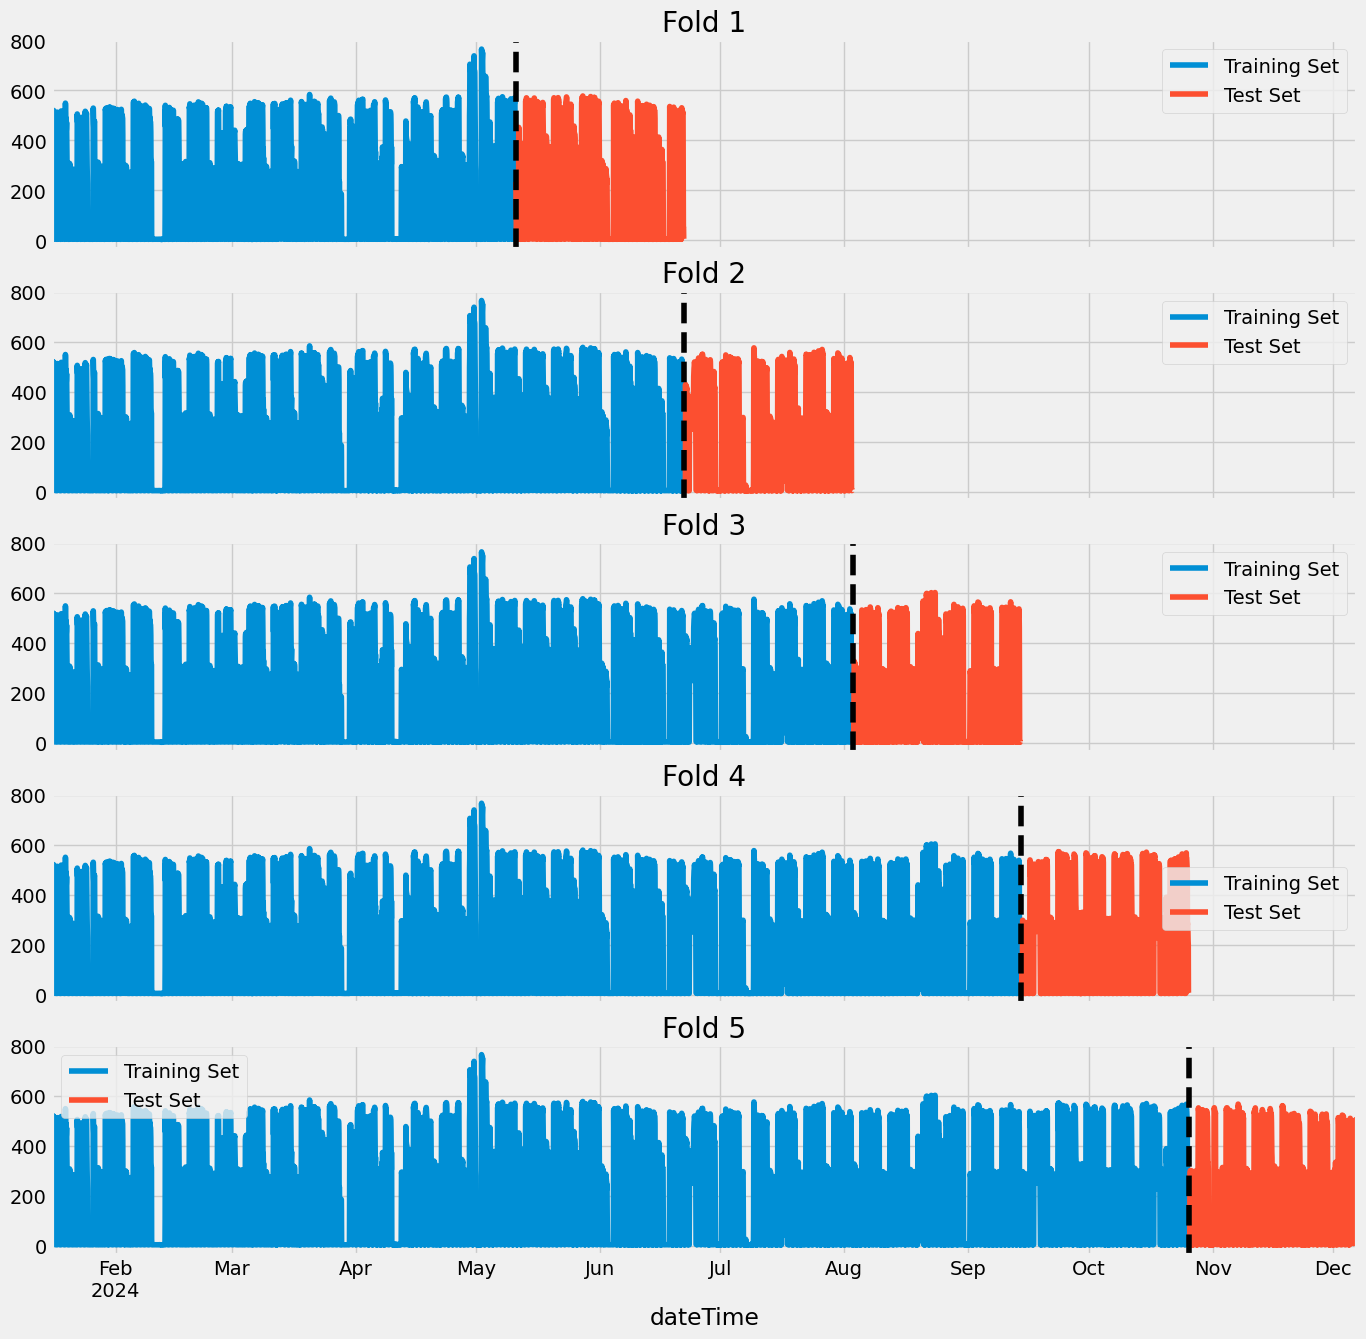

In [ ]:
# Create Time Series Split
tss = TimeSeriesSplit(n_splits=5, test_size=24*14*3, gap=0)
df = df.sort_index()
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(15,15))

fold = 0

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['activePowerT'].plot(ax=axs[fold], label='Training Set',title=f'Fold {fold+1}')
    test['activePowerT'].plot(ax=axs[fold], label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    axs[fold].legend(['Training Set', 'Test Set'])
    fold+=1

In [ ]:
# Feature Creations
def create_features(df):
    df= df.copy()
    target_mapT = df['activePowerT'].to_dict()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['activePowerT_lag1']= (df.index-pd.Timedelta('7 days')).map(target_mapT)
    df['activePowerT_lag2']= (df.index-pd.Timedelta('14 days')).map(target_mapT)
    df.dropna(inplace=True)

    return df


## Sequence Creation

In [ ]:
# Sequence Creation
def df_to_X_y1(df, window_size=5):
  df = df.copy()
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size][0]
    y.append(label)

  return np.array(X), np.array(y)

# Plot Predictions
def plot_predictions(model, X, y, start=20, end=120):
  predictions = model.predict(X).flatten()
  val_df = pd.DataFrame(data={'Val Predictions': predictions, 'Actuals':y})

  plt.plot(val_df['Val Predictions'][start:end])
  plt.plot(val_df['Actuals'][start:end])
  plt.show()


# To calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# To calculate MASE
def mean_absolute_scaled_error(y_true, y_pred):
    n = len(y_true)
    d = np.abs(np.diff(y_true)).sum()/(n-1)
    errors = np.abs(y_true - y_pred)
    return errors.mean()/d

## Multivariate LSTM Model

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 97116.6016 - root_mean_squared_error: 311.5597 - val_loss: 93706.3984 - val_root_mean_squared_error: 306.1150
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 84624.1016 - root_mean_squared_error: 290.8837 - val_loss: 82228.7109 - val_root_mean_squared_error: 286.7555
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 75999.3906 - root_mean_squared_error: 275.5594 - val_loss: 70680.6797 - val_root_mean_squared_error: 265.8584
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 63155.2656 - root_mean_squared_error: 251.2738 - val_loss: 60863.6289 - val_root_mean_squared_error: 246.7056
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 57329.9219 - root_mean_squared_error: 239.4068 - val_loss: 54470.1914 - val_root_mean_squared_error: 233.3885
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 51897.7266 - root_mean_squared_error: 227.7919 - val_loss: 48636.2070 - val_root_mean_squared_erro

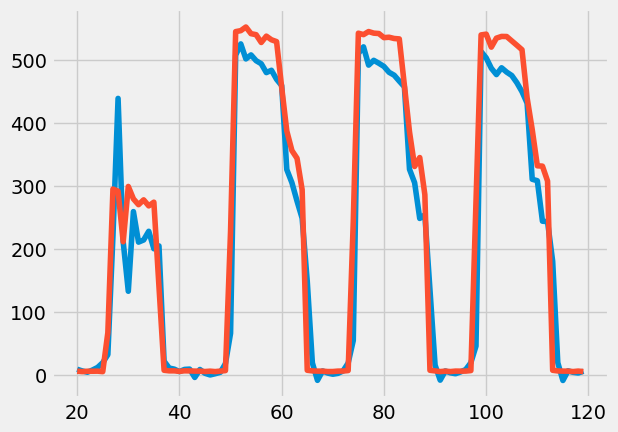

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")
df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df= df[['activePowerT']]
df = create_features(df)
X, y = df_to_X_y1(df)
fold = 0
preds= []
score_mse = []
score_mae = []
score_mape = []
score_mase=[]
score_err= []
score_r1 = []
scores = []
epochs1= []
training1 = []
test1= []


for train_idx, val_idx in tss.split(df):
    X1_train,  y_train = X[min(train_idx):max(train_idx)], y[min(train_idx):max(train_idx)]
    X1_test, y_test = X[min(val_idx):max(val_idx)], y[min(val_idx):max(val_idx)]

    model1 = Sequential()
    model1.add(InputLayer((5, 7)))
    model1.add(LSTM(32,return_sequences=True,dropout=0.15))
    model1.add(LSTM(32))
    model1.add(Dense(32, activation='relu'))
    model1.add(Dense(1, activation='linear'))

    cp = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min'
    )

    model1.compile(loss=MeanSquaredError(), metrics=[RootMeanSquaredError()], optimizer=Adam(learning_rate=0.001))
    history = model1.fit(X1_train, y_train, validation_data=(X1_test, y_test), epochs=50, callbacks=[cp],verbose=1)

    predictions = model1.predict(X1_test).flatten()


    test_df = pd.DataFrame(data={'Val Predictions': predictions, 'Actuals':y_test})
    score_mae.append(mean_absolute_error(test_df['Val Predictions'], test_df['Actuals']))
    score_mape.append(mean_absolute_percentage_error(test_df['Val Predictions'], test_df['Actuals']))
    score_mase.append(mean_absolute_scaled_error(test_df['Val Predictions'], test_df['Actuals']))
    score_mse.append((np.sqrt(test_df['Val Predictions'], test_df['Actuals'])).mean())
    score_err.append((abs(statistics.mean(y_test)-statistics.mean(predictions))/statistics.mean(y_test) * 100))

    result1 = pd.DataFrame(history.history)
    epochs1.append(len(result1['loss']))
    training1.append(result1['root_mean_squared_error'])
    test1.append(result1['val_root_mean_squared_error'])

print(f'Average score (MSE): {np.mean(score_mse):0.2f}')
print(f'Average score (MAE): {np.mean(score_mae):0.2f}')
print(f'Average score (MAPE): {np.mean(score_mape):0.2f}')
print(f'Average score (MASE): {np.mean(score_mase):0.2f}')
print(f'Average score (Error): {np.mean(score_err):0.2f}')

plot_predictions(model1, X1_test, y_test)



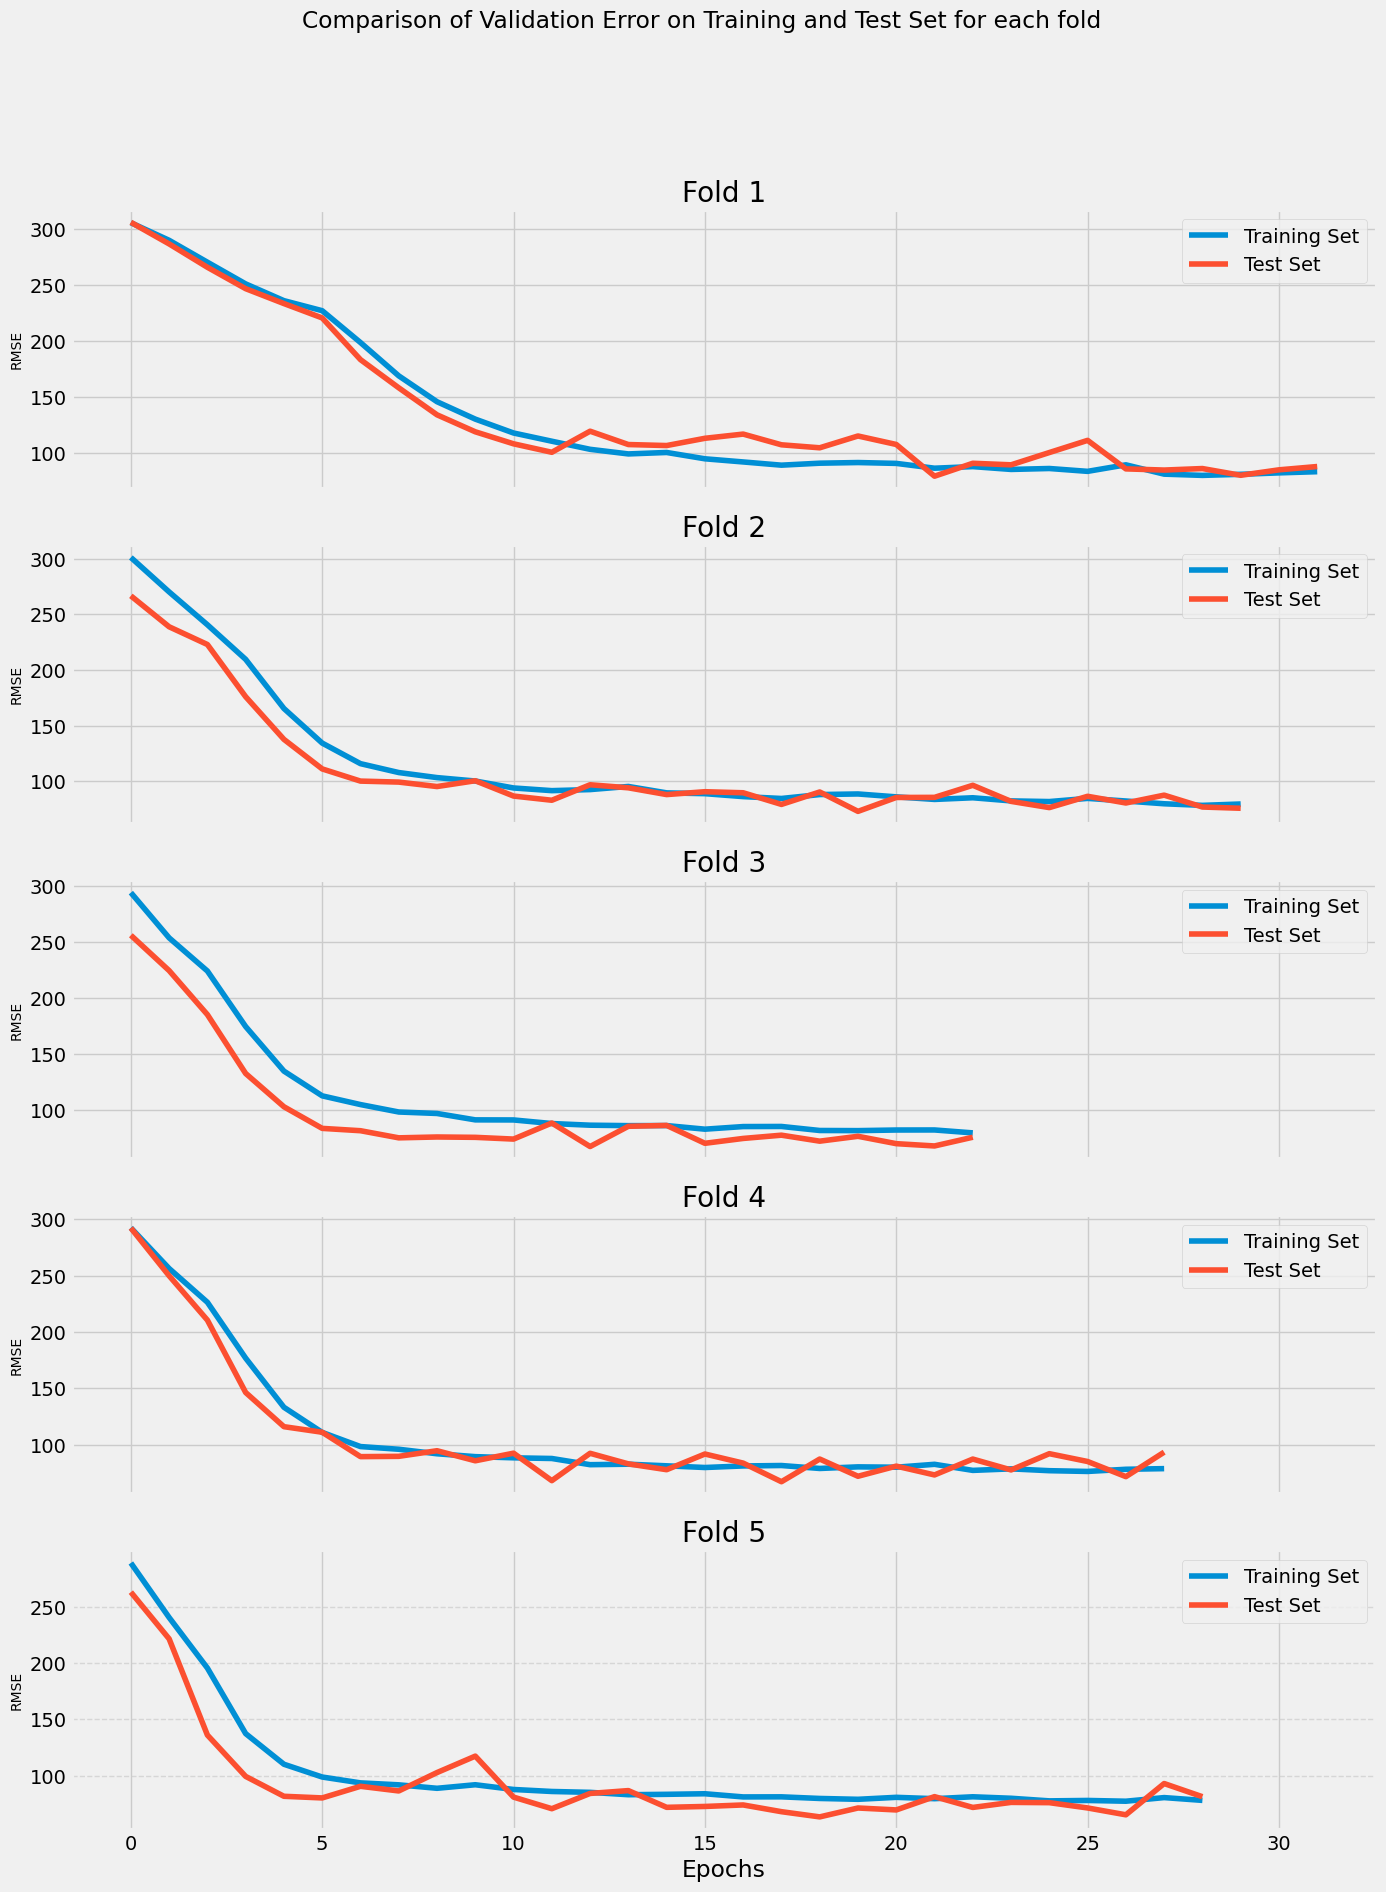

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(15,20))
for i in range(5):
  x_axis = range(0, epochs1[i])
  axs[i].plot(x_axis, training1[i], label='Train')
  axs[i].plot(x_axis, test1[i], label='Test')
  axs[i].set_title(f'Fold {i+1}')
  axs[i].legend()
  axs[i].legend(['Training Set', 'Test Set'])
  axs[i].set_ylabel('RMSE',fontsize=10)
plt.xlabel('Epochs')
plt.suptitle('Comparison of Validation Error on Training and Test Set for each fold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.savefig('/content/drive/MyDrive/Images/LSTM/LSTM1')
plt.show()

## Univariate LSTM Model

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 97773.5000 - root_mean_squared_error: 312.5926 - val_loss: 93032.4062 - val_root_mean_squared_error: 305.0121
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 86823.1719 - root_mean_squared_error: 294.5564 - val_loss: 82635.9922 - val_root_mean_squared_error: 287.4648
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 77331.5781 - root_mean_squared_error: 278.0362 - val_loss: 71384.1875 - val_root_mean_squared_error: 267.1782
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 65169.1758 - root_mean_squared_error: 255.2524 - val_loss: 61562.8945 - val_root_mean_squared_error: 248.1187
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 56261.6406 - root_mean_squared_error: 237.0589 - val_loss: 45058.4531 - val_root_mean_squared_error: 212.2698
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 38812.8828 - root_mean_squared_error: 196.9416 - val_loss: 31621.6914 - val_root_mean_squared_erro

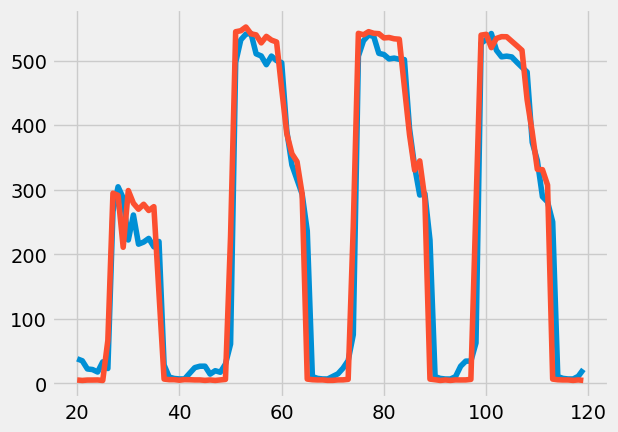

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")
df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df= df[['activePowerT']]
X, y = df_to_X_y1(df)

fold = 0
preds= []
score_mse = []
score_mae = []
score_mape = []
score_smape = []
score_err= []
score_r2 = []
scores = []
epochs2= []
training2 = []
test2= []

for train_idx, val_idx in tss.split(df):
    X2_train,  y_train = X[min(train_idx):max(train_idx)], y[min(train_idx):max(train_idx)]
    X2_test, y_test = X[min(val_idx):max(val_idx)], y[min(val_idx):max(val_idx)]

    model2 = Sequential()
    model2.add(InputLayer((5, 1)))
    model2.add(LSTM(32,return_sequences=True))
    model2.add(LSTM(32))
    model2.add(Dense(32, activation='relu'))
    model2.add(Dense(1, activation='linear'))

    cp = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min'
    )

    model2.compile(loss=MeanSquaredError(), metrics=[RootMeanSquaredError()], optimizer=Adam(learning_rate=0.001))
    history = model2.fit(X2_train, y_train, validation_data=(X2_test, y_test), epochs=30, callbacks=[cp],verbose=1)

    predictions = model2.predict(X2_test).flatten()



    test_df = pd.DataFrame(data={'Val Predictions': predictions, 'Actuals':y_test})
    score_mae.append(mean_absolute_error(test_df['Val Predictions'], test_df['Actuals']))
    score_mape.append(mean_absolute_percentage_error(test_df['Val Predictions'], test_df['Actuals']))
    score_smape.append(np.mean((np.abs(test_df['Actuals'] - test_df['Val Predictions'])) /((np.abs(test_df['Val Predictions']+np.abs(test_df['Actuals'])) / 2))) * 100)
    score_mse.append((np.sqrt(test_df['Val Predictions'], test_df['Actuals'])).mean())
    score_err.append((abs(statistics.mean(y_test)-statistics.mean(predictions))/statistics.mean(y_test) * 100))

    result2 = pd.DataFrame(history.history)
    epochs2.append(len(result2['loss']))
    training2.append(result2['root_mean_squared_error'])
    test2.append(result2['val_root_mean_squared_error'])

print(f'Average score (MSE): {np.mean(score_mse):0.2f}')
print(f'Average score (MAE): {np.mean(score_mae):0.2f}')
print(f'Average score (MAPE): {np.mean(score_mape):0.2f}')
print(f'Average score (SMAPE): {np.mean(score_smape):0.2f}')
print(f'Average score (Error): {np.mean(score_err):0.2f}')

plot_predictions(model2, X2_test, y_test)

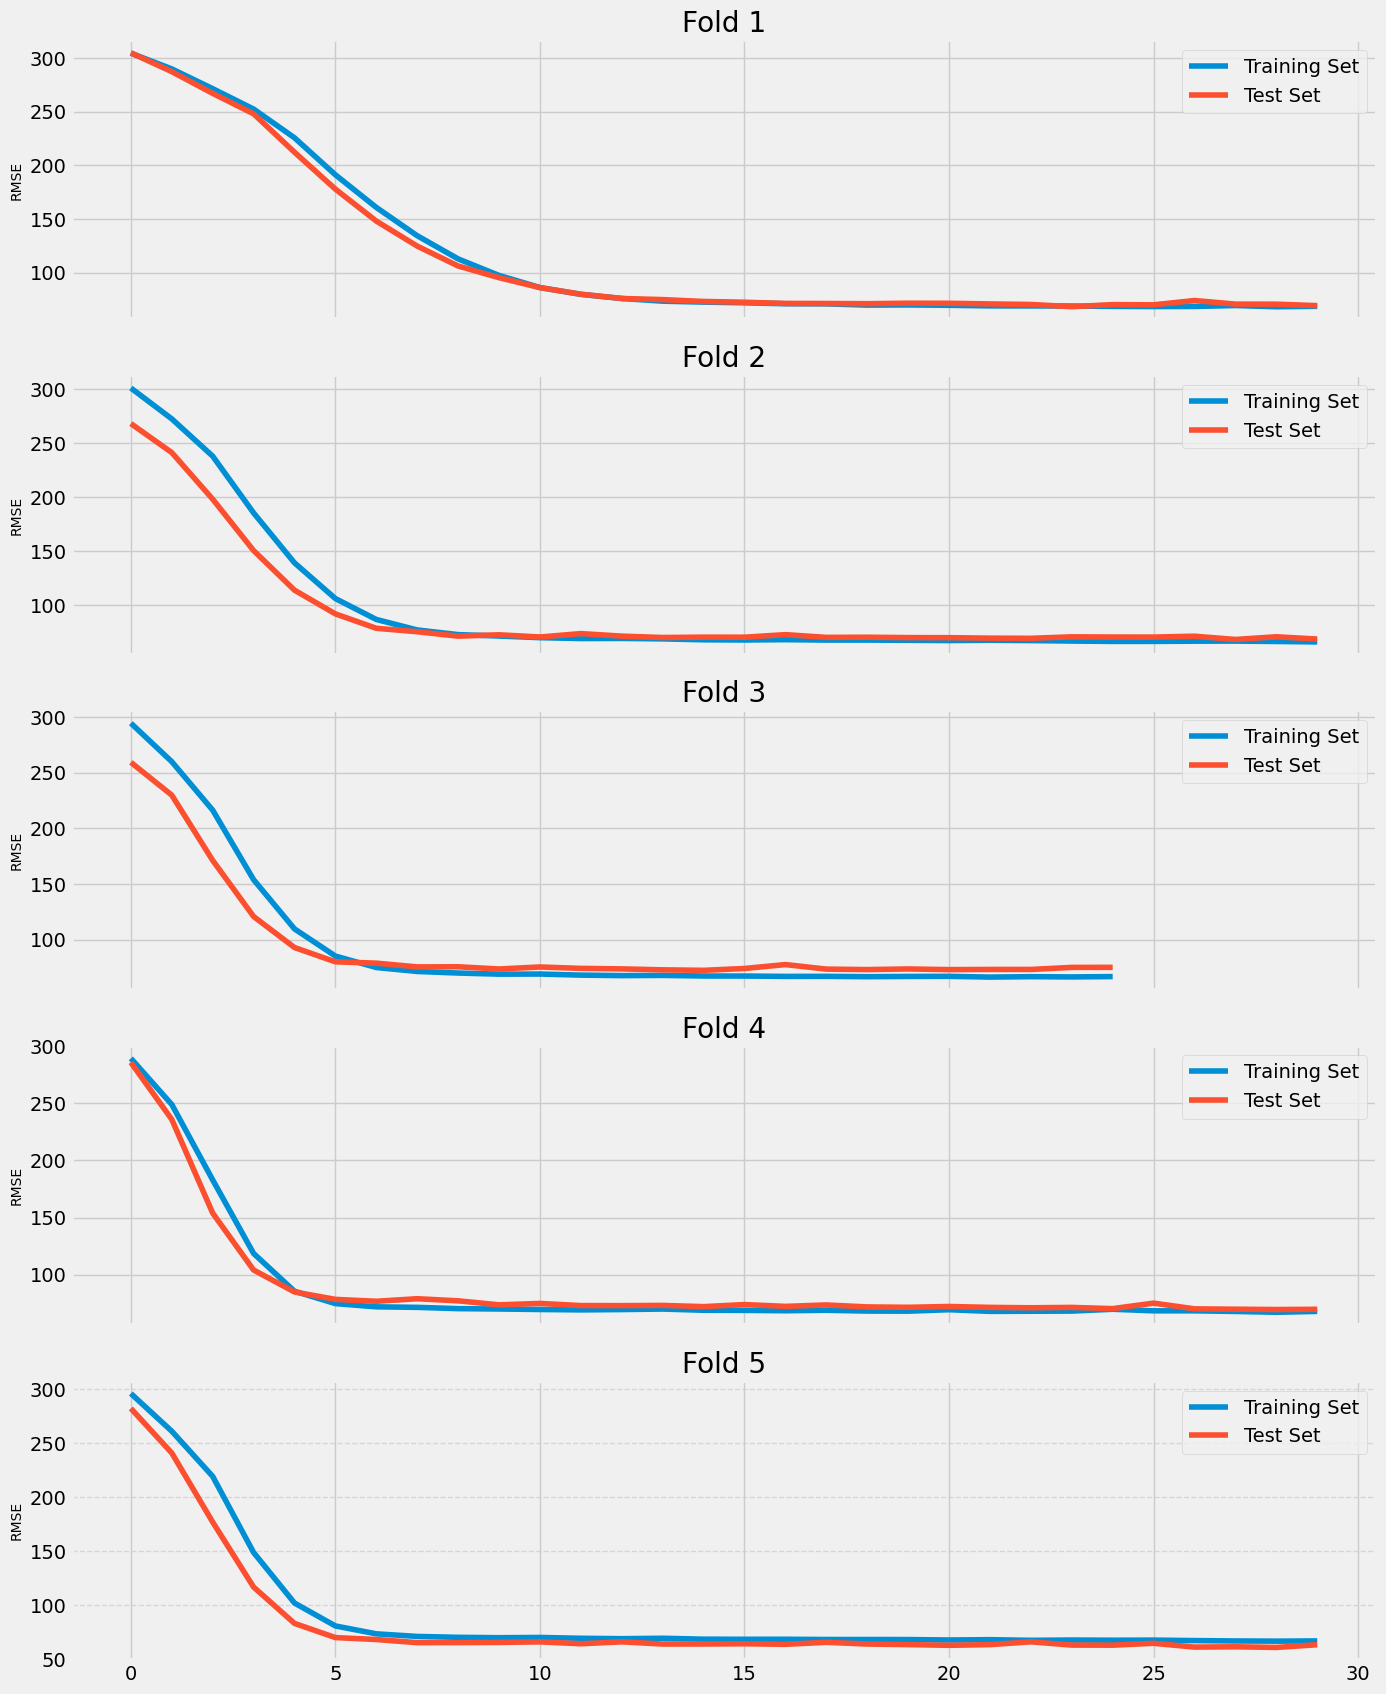

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(15,20))
for i in range(5):
  x_axis = range(0, epochs2[i])
  axs[i].plot(x_axis, training2[i], label='Train')
  axs[i].plot(x_axis, test2[i], label='Test')
  axs[i].set_title(f'Fold {i+1}')
  axs[i].legend()
  axs[i].legend(['Training Set', 'Test Set'])
  axs[i].set_ylabel('RMSE',fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.savefig('/content/drive/MyDrive/Images/LSTM/LSTM2')
plt.show()

## Results

In [ ]:
predictions1 = model1.predict(X1_test).flatten()
predictions2 = model2.predict(X2_test).flatten()
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")
df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df= df[['activePowerT']]
df = create_features(df)
df = df.reset_index()
dftest = df.iloc[min(val_idx+4):max(val_idx)]
dftest.set_index('dateTime', inplace=True)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


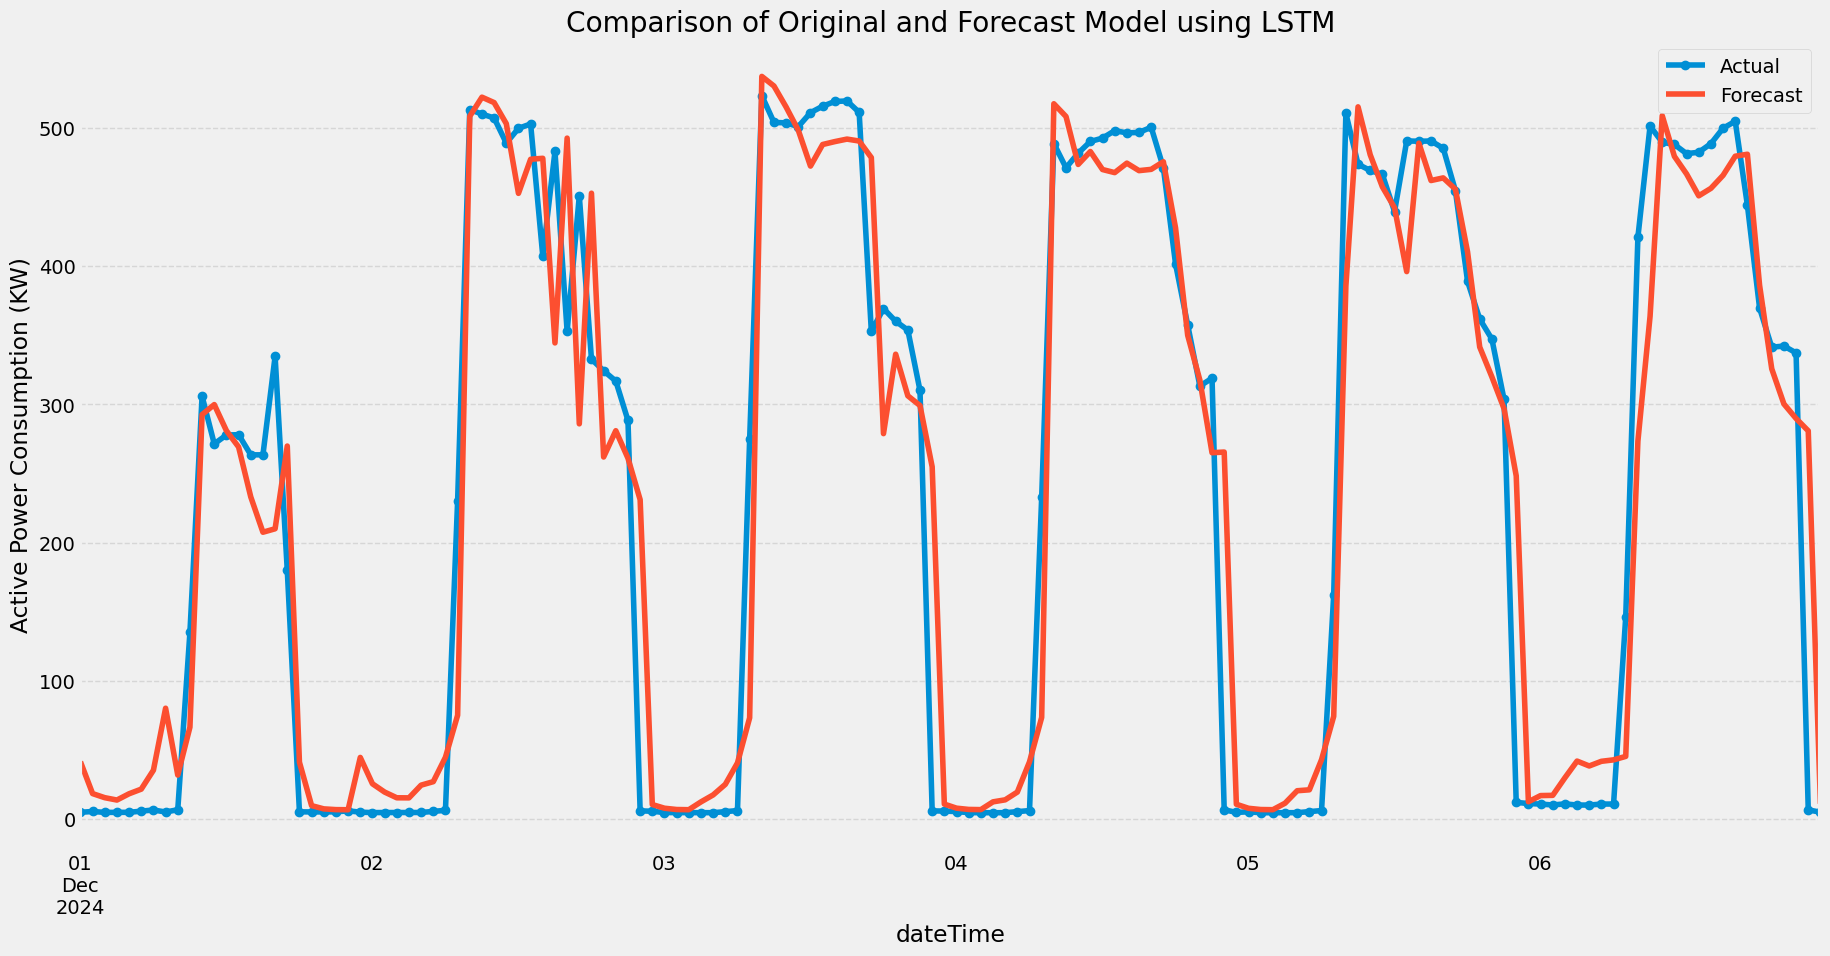

In [ ]:
val_df1 = pd.DataFrame(data={'Val Predictions': predictions1, 'Actuals':y_test},index=dftest.index)
val_df2 = pd.DataFrame(data={'Val Predictions': predictions2, 'Actuals':y_test},index=dftest.index)

ax = val_df2.loc[(val_df2.index >= '2024-12-01') & (val_df2.index < '2024-12-08')].plot(y=['Actuals'],title='Comparison of Original and Forecast Model using LSTM',xlabel='Date',ylabel='Active Power Consumption (KW)',figsize=(20,10),marker="o")
val_df2.loc[(val_df2.index >= '2024-12-01') & (val_df2.index < '2024-12-08')].plot(y=['Val Predictions'],ax=ax)

ax.legend(['Actual','Forecast'],loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig = ax.get_figure()
fig.savefig('/content/drive/MyDrive/Images/LSTM/Results')
plt.show()

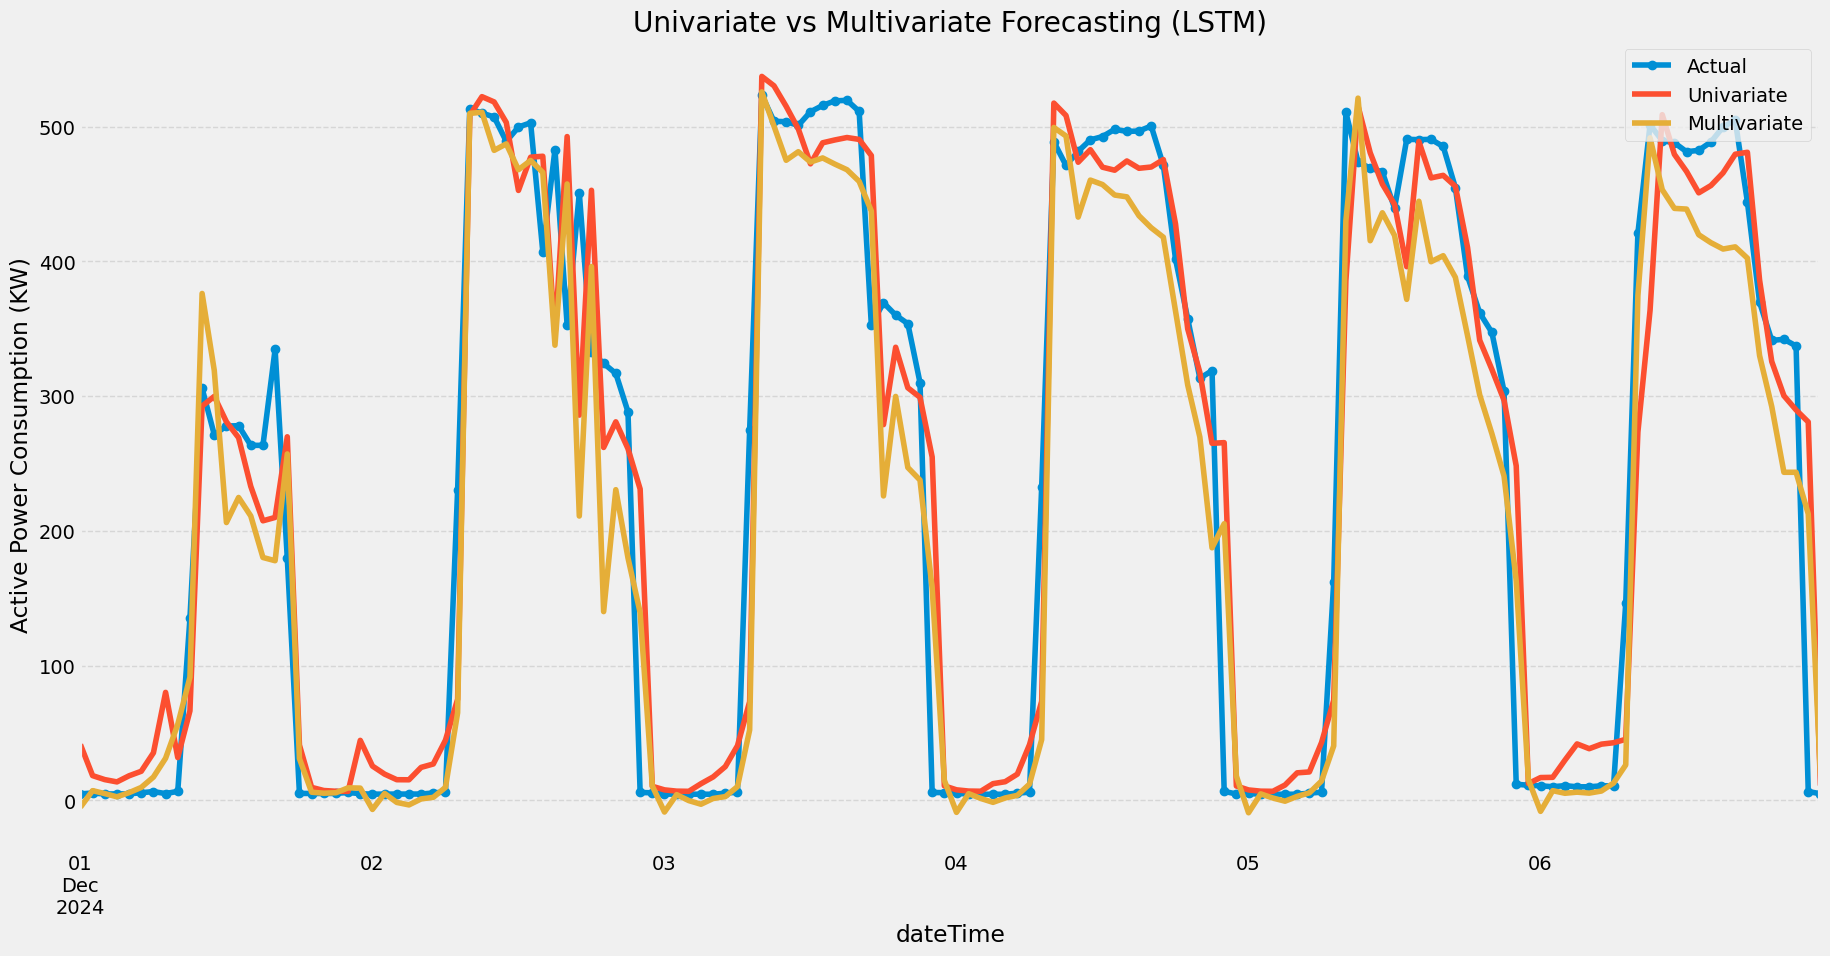

In [ ]:
# To plot comparison
ax = val_df2.loc[(val_df2.index >= '2024-12-01') & (val_df2.index < '2024-12-08')].plot(y=['Actuals'],title='Univariate vs Multivariate Forecasting (LSTM)',xlabel='Date',ylabel='Active Power Consumption (KW)',figsize=(20,10),marker="o")
val_df2.loc[(val_df2.index >= '2024-12-01') & (val_df2.index < '2024-12-08')].plot(y=['Val Predictions'],ax=ax)

val_df1.loc[(val_df1.index >= '2024-12-01') & (val_df1.index < '2024-12-08')].plot(y=['Val Predictions'],ax=ax)

ax.legend(['Actual','Univariate','Multivariate'],loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig = ax.get_figure()
fig.savefig('/content/drive/MyDrive/Images/LSTM/Comparison')
plt.show()

## Out of Sample Forecasts

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 66061.5078 - root_mean_squared_error: 255.9802
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - loss: 49457.6797 - root_mean_squared_error: 222.3906
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - loss: 49398.5078 - root_mean_squared_error: 222.2572
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - loss: 46405.1367 - root_mean_squared_error: 215.3834
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - loss: 39273.4766 - root_mean_squared_error: 198.1731
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - loss: 38717.0820 - root_mean_squared_error: 196.7657
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 38959.5352 - root_mean_squared_error: 197.3780
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - loss: 39107.2422 - root_mean_squared_error: 197.7546
Epoch 9/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - loss: 38916.9180 - root_mean_squared_error: 197.2724
Epoch 10/30
236/236

<Axes: title={'center': 'Future Predictions'}>

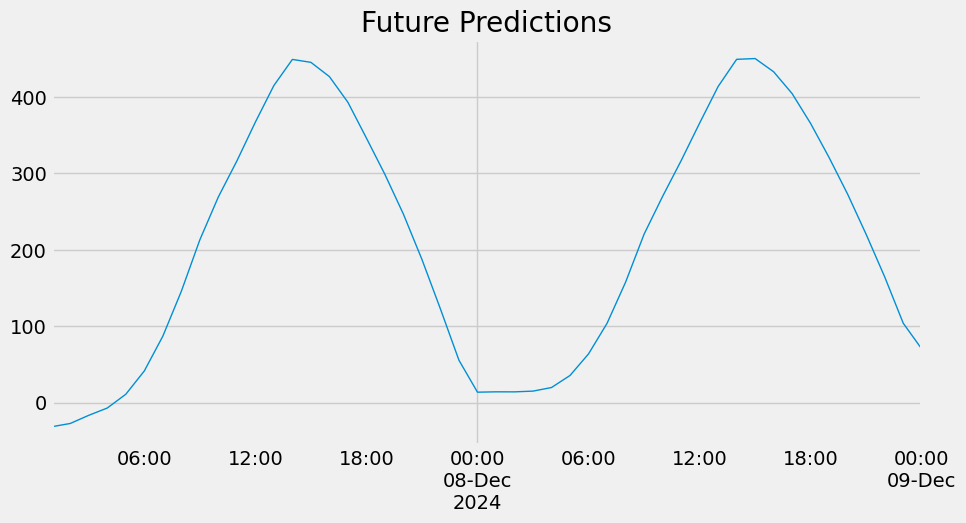

In [ ]:
df = df[['activePowerT']]
df = df.copy()
df_as_np = df.to_numpy()
X = []
Y = []
n_lookback = 24*10
n_forecast = 24*2
for i in range(n_lookback,len(y)-n_forecast+1):
  X.append(y[i-n_lookback:i])
  Y.append(y[i:i+n_forecast])

X = np.array(X)
Y = np.array(Y)



model3 = Sequential()
model3.add(InputLayer((n_lookback, 1)))
model3.add(LSTM(32))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(n_forecast, activation='linear'))

cp = EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True,
mode='min'
)

model3.compile(loss=MeanSquaredError(), metrics=[RootMeanSquaredError()], optimizer=Adam(learning_rate=0.01))
history = model3.fit(X, Y,epochs=30, callbacks=[cp],verbose=1)


X_ = y[-n_lookback:]
X_ = X_.reshape(1,n_lookback,1)
Y_ = model3.predict(X_).reshape(-1,1)

# Create Future Dataframe



future = pd.date_range(start=df.index.max()+pd.Timedelta('1 hour'),freq='1h', periods=n_forecast)
future_df = pd.DataFrame(index=future)
future_df['isFuture']= True
df['isFuture']=False
df_and_future = pd.concat([df,future_df])
future_w_features = df_and_future.query('isFuture').copy()
future_w_features['pred']= model3.predict(X_).flatten()
future_w_features['pred'].plot(figsize=(10,5),
                               ms=1,
                               lw=1,
                               title='Future Predictions'
                               )


## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import cross_val_score

def objective(trial):

    dropout = trial.suggest_uniform('dropout', 0.1, 0.5)
    # Additional hyperparameters can be defined here
    model1 = Sequential()
    model1.add(InputLayer((5, 1)))
    model1.add(LSTM(32,dropout=dropout))
    model1.add(Dense(32, activation='relu'))
    model1.add(Dense(1, activation='linear'))
    predictions = model1.predict(X2_test).flatten()
    test_df = pd.DataFrame(data={'Val Predictions': predictions, 'Actuals':y_test})
    score_mae.append(mean_absolute_error(test_df['Val Predictions'], test_df['Actuals']))
    return score_mae


In [ ]:
study = optuna.create_study(direction='maximize',sampler=optuna.samplers.RandomSampler())
study.optimize(objective, n_trials=100)

In [ ]:
print('Best hyperparameters: ', study.best_params)